# Exploratory Data Analysis (EDA)

This notebook explores the raw Olist datasets before building the processed analytical layer.

Focus areas:
- dataset structure
- missing values
- duplicates
- distribution checks
- join sanity checks

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
categories = pd.read_csv("../data/raw/product_category_name_translation.csv")

datasets = {
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "categories": categories,
}

In [3]:
overview = pd.DataFrame(
    {
        "dataset": list(datasets.keys()),
        "rows": [df.shape[0] for df in datasets.values()],
        "columns": [df.shape[1] for df in datasets.values()],
        "duplicates": [df.duplicated().sum() for df in datasets.values()],
    }
)

overview

,dataset,rows,columns,duplicates
0,orders,99441,8,0
1,items,112650,7,0
2,payments,103886,5,0
3,reviews,100000,7,0
4,customers,99441,5,0
5,products,32951,9,0
6,sellers,3095,4,0
7,categories,71,2,0


In [4]:
missing_summary = []

for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if not missing.empty:
        temp = pd.DataFrame(
            {
                "dataset": name,
                "column": missing.index,
                "missing_count": missing.values,
                "missing_pct": (missing.values / len(df) * 100).round(2),
            }
        )
        missing_summary.append(temp)

missing_summary_df = pd.concat(missing_summary, ignore_index=True)
missing_summary_df

,dataset,column,missing_count,missing_pct
0,orders,order_delivered_customer_date,2965,2.98
1,orders,order_delivered_carrier_date,1783,1.79
2,orders,order_approved_at,160,0.16
3,reviews,review_comment_title,88285,88.28
4,reviews,review_comment_message,58247,58.25
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
9,products,product_weight_g,2,0.01


In [14]:
print(
    """
EDA interpretation notes:
- Missing review comments are expected and should not automatically be treated as data quality issues.
- Missing delivery timestamps can occur for orders not yet delivered or canceled.
- Missing product category translations should be tracked, then mapped to 'unknown' in the processed layer.
- Missing review score should be evaluated separately from missing text comments.
"""
)


EDA interpretation notes:
- Missing review comments are expected and should not automatically be treated as data quality issues.
- Missing delivery timestamps can occur for orders not yet delivered or canceled.
- Missing product category translations should be tracked, then mapped to 'unknown' in the processed layer.
- Missing review score should be evaluated separately from missing text comments.



In [5]:
order_status_counts = orders["order_status"].value_counts()
order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

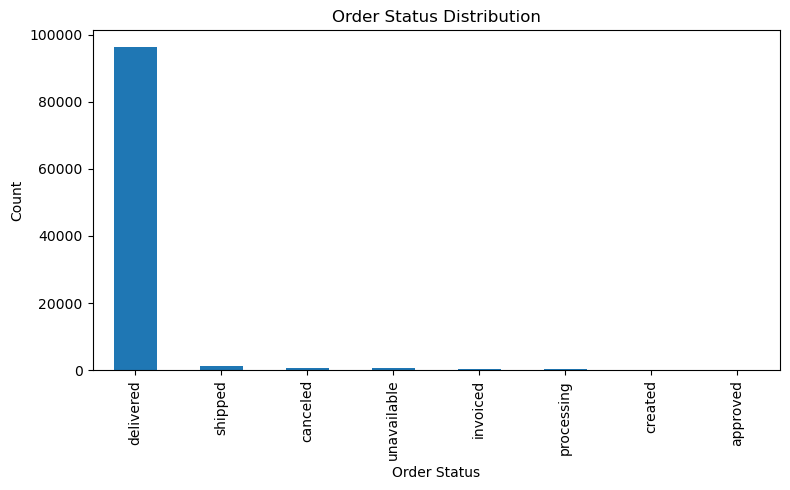

In [6]:
plt.figure(figsize=(8, 5))
order_status_counts.plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:
reviews["review_score"] = pd.to_numeric(reviews["review_score"], errors="coerce")
reviews["review_score"].value_counts().sort_index()

review_score
1    11858
2     3235
3     8287
4    19200
5    57420
Name: count, dtype: int64

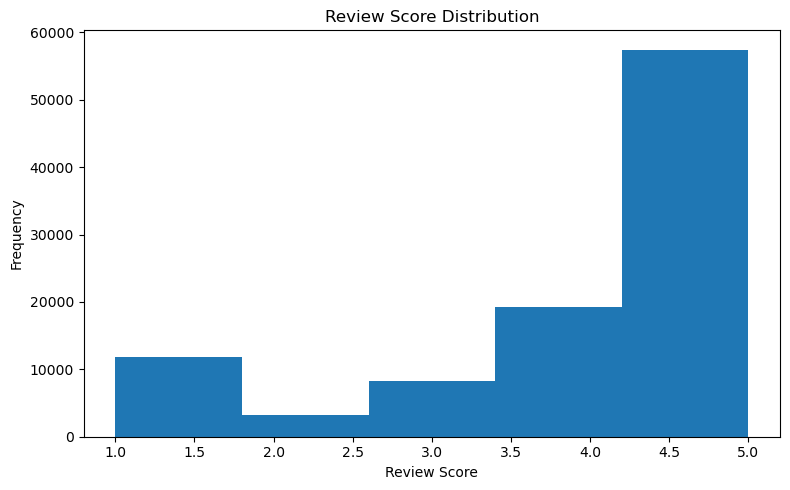

In [8]:
plt.figure(figsize=(8, 5))
reviews["review_score"].dropna().plot(kind="hist", bins=5)
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [9]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [10]:
products_enriched = products.merge(categories, on="product_category_name", how="left")

category_missing = products_enriched["product_category_name_english"].isna().sum()
total_products = len(products_enriched)

print(f"Missing translated category rows: {category_missing}")
print(f"Percentage: {category_missing / total_products * 100:.2f}%")

Missing translated category rows: 623
Percentage: 1.89%


In [11]:
merged_check = (
    items.merge(orders, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(products_enriched, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

print("Merged shape:", merged_check.shape)
print("Missing orders after join:", merged_check["order_id"].isna().sum())
print("Missing customers after join:", merged_check["customer_id"].isna().sum())
print("Missing products after join:", merged_check["product_id"].isna().sum())
print("Missing sellers after join:", merged_check["seller_id"].isna().sum())

Merged shape: (112650, 30)
Missing orders after join: 0
Missing customers after join: 0
Missing products after join: 0
Missing sellers after join: 0


In [13]:
print(
    """
EDA summary:
1. The source data is relational and requires careful merging.
2. Analytical grain must be controlled because order items create repeated order-level attributes.
3. Missingness is partly structural, not purely data quality failure.
4. Review and delivery metrics should be modeled at the order level downstream.
"""
)


EDA summary:
1. The source data is relational and requires careful merging.
2. Analytical grain must be controlled because order items create repeated order-level attributes.
3. Missingness is partly structural, not purely data quality failure.
4. Review and delivery metrics should be modeled at the order level downstream.

